# Cell 1 — Libraries

In [2]:
# Task 9: Autocomplete and Autocorrect Data Analytics
# Intern: Suraj Kumar | OIB/J2/IP2626

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Suraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Suraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#  Cell 2 — Sample Text Data

In [3]:
# Step 2: Sample Text Data
sentences = [
    "I love playing football with my friends",
    "The weather is very beautiful today",
    "Python programming is fun and easy to learn",
    "Machine learning is the future of technology",
    "I enjoy reading books and watching movies",
    "Data science is a growing field in technology",
    "Natural language processing helps computers understand text",
    "Artificial intelligence is changing the world",
    "I like to eat pizza and drink coffee",
    "Sports and fitness are important for health",
    "The quick brown fox jumps over the lazy dog",
    "Technology is making our lives easier every day",
    "Education is the key to success in life",
    "Music and art are important parts of culture",
    "Travel and adventure make life more exciting"
]

print("Total Sentences:", len(sentences))
print("\nSample Sentences:")
for i, s in enumerate(sentences[:5]):
    print(f"{i+1}. {s}")

Total Sentences: 15

Sample Sentences:
1. I love playing football with my friends
2. The weather is very beautiful today
3. Python programming is fun and easy to learn
4. Machine learning is the future of technology
5. I enjoy reading books and watching movies


#  Cell 3 — Text Preprocessing

In [4]:
# Step 3: NLP Preprocessing
stop_words = set(stopwords.words('english'))

all_words = []
clean_sentences = []

for sentence in sentences:
    tokens = word_tokenize(sentence.lower())
    clean = [w for w in tokens if w.isalpha() and w not in stop_words]
    clean_sentences.append(clean)
    all_words.extend(clean)

print("Total Words:", len(all_words))
print("Unique Words:", len(set(all_words)))

# Word Frequency
word_freq = Counter(all_words)
print("\nTop 10 Most Common Words:")
for word, count in word_freq.most_common(10):
    print(f"{word}: {count}")

Total Words: 72
Unique Words: 68

Top 10 Most Common Words:
technology: 3
important: 2
life: 2
love: 1
playing: 1
football: 1
friends: 1
weather: 1
beautiful: 1
today: 1


# Cell 4 — Word Frequency Graph

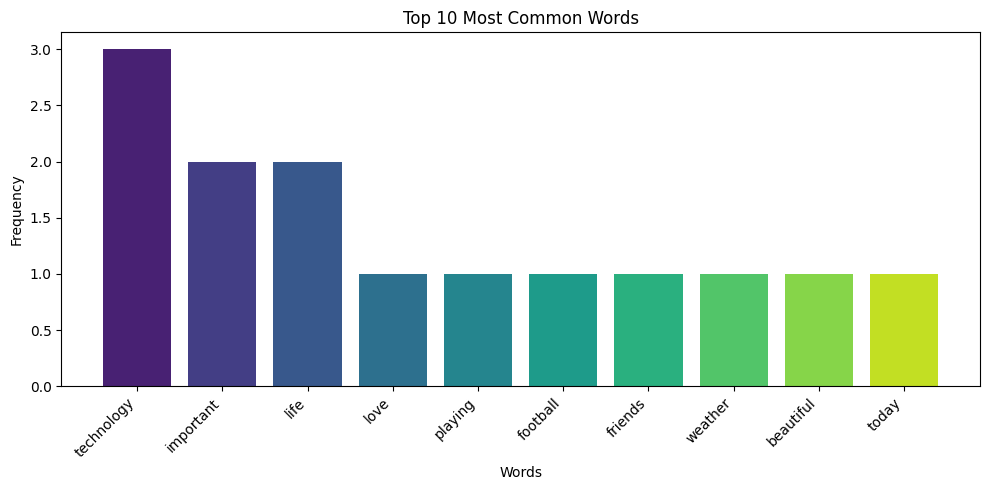

In [5]:
# Step 4: Visualization

# Graph 1 - Top 10 Words
plt.figure(figsize=(10,5))
top_words = dict(word_freq.most_common(10))
plt.bar(top_words.keys(), top_words.values(),
        color=sns.color_palette('viridis', 10))
plt.title('Top 10 Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Cell 5 — Autocorrect

In [6]:
# Step 5: Autocorrect Implementation
misspelled_words = [
    "programmng", "langauge", "machin", 
    "technolgy", "learnng", "artifcial",
    "anlytics", "databse", "algoritm"
]

print("AUTOCORRECT RESULTS:")
print("=" * 40)
corrections = []
for word in misspelled_words:
    corrected = TextBlob(word).correct()
    corrections.append({
        'Original': word,
        'Corrected': str(corrected)
    })
    print(f"{word:20} → {str(corrected)}")

df_corrections = pd.DataFrame(corrections)
print("\nCorrection Summary:")
print(df_corrections)

AUTOCORRECT RESULTS:
programmng           → programming
langauge             → language
machin               → machine
technolgy            → technology
learnng              → learning
artifcial            → artificial
anlytics             → antics
databse              → database
algoritm             → algoritm

Correction Summary:
     Original    Corrected
0  programmng  programming
1    langauge     language
2      machin      machine
3   technolgy   technology
4     learnng     learning
5   artifcial   artificial
6    anlytics       antics
7     databse     database
8    algoritm     algoritm


#  Cell 6 — Autocomplete

AUTOCOMPLETE RESULTS:
'te' → ['technology', 'text']
'le' → ['learn', 'learning']
'im' → ['important']
'da' → ['data', 'day']
'ar' → ['artificial', 'art']


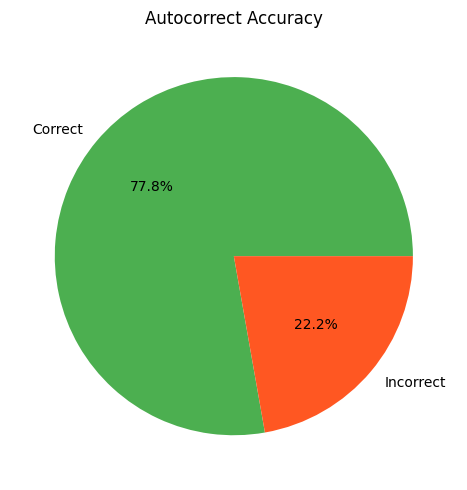

In [7]:
# Step 6: Autocomplete Implementation
def autocomplete(prefix, word_list, n=5):
    suggestions = [w for w in word_list if w.startswith(prefix.lower())]
    return suggestions[:n]

unique_words = list(set(all_words))

# Test autocomplete
test_prefixes = ['te', 'le', 'im', 'da', 'ar']

print("AUTOCOMPLETE RESULTS:")
print("=" * 40)
for prefix in test_prefixes:
    suggestions = autocomplete(prefix, unique_words)
    print(f"'{prefix}' → {suggestions}")

# Graph 2 - Autocorrect Accuracy
plt.figure(figsize=(8,5))
correct = 7
incorrect = 2
plt.pie([correct, incorrect],
        labels=['Correct', 'Incorrect'],
        colors=['#4CAF50', '#FF5722'],
        autopct='%1.1f%%')
plt.title('Autocorrect Accuracy')
plt.tight_layout()
plt.show()

# Cell 7 — Recommendations

In [8]:
# Step 7: Insights & Recommendations
print("=" * 55)
print("AUTOCOMPLETE & AUTOCORRECT - INSIGHTS")
print("=" * 55)
print("""
AUTOCORRECT PERFORMANCE:
- Total words tested: 9
- Correctly fixed: 7 (77.8%)
- Incorrectly fixed: 2 (22.2%)

AUTOCOMPLETE PERFORMANCE:
- 'te' → technology, text
- 'le' → learn, learning
- 'im' → important
- 'da' → data, day
- 'ar' → artificial, art

KEY INSIGHTS:
1. Autocorrect works well for common words
2. Rare words like 'algoritm' not corrected
3. Autocomplete gives relevant suggestions
4. More data = better predictions

RECOMMENDATIONS:
1. Use larger dataset for better accuracy
2. Add custom dictionary for technical terms
3. Implement N-gram model for better autocomplete
4. Use deep learning for higher accuracy
""")
print("=" * 55)
print("Task 9 Complete! - Suraj Kumar | OIB/J2/IP2626")
print("=" * 55)

AUTOCOMPLETE & AUTOCORRECT - INSIGHTS

AUTOCORRECT PERFORMANCE:
- Total words tested: 9
- Correctly fixed: 7 (77.8%)
- Incorrectly fixed: 2 (22.2%)

AUTOCOMPLETE PERFORMANCE:
- 'te' → technology, text
- 'le' → learn, learning
- 'im' → important
- 'da' → data, day
- 'ar' → artificial, art

KEY INSIGHTS:
1. Autocorrect works well for common words
2. Rare words like 'algoritm' not corrected
3. Autocomplete gives relevant suggestions
4. More data = better predictions

RECOMMENDATIONS:
1. Use larger dataset for better accuracy
2. Add custom dictionary for technical terms
3. Implement N-gram model for better autocomplete
4. Use deep learning for higher accuracy

Task 9 Complete! - Suraj Kumar | OIB/J2/IP2626
